In [1]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
# import plotly.io as pio
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf

# GMM
from sklearn.mixture import GaussianMixture

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
# pio.templates.default = 'plotly'
# pio.templates['plotly'].layout.width = 1000
# pio.templates['plotly'].layout.height = 800

In [3]:
raw = "C:\\Users\\Taavi\\Desktop\\BPhil\\Raw data\\"
clean = "C:\\Users\\Taavi\\Desktop\\BPhil\\Clean data\\"

In [4]:
viols = pd.read_csv(clean + 'viols_transformations.csv')
crimes = pd.read_csv(clean + 'crimes_transformations.csv')

In [5]:
parcels = pd.concat([viols, crimes.iloc[:, 5:]], axis = 1)

In [6]:
def process_data(data, transformer, scaler):
    np.random.seed(0)

    if transformer == 'log':
        transformed = np.log1p(data)
    elif transformer == 'sqrt':
        transformed = np.sqrt(data)

    if scaler == 'standard':
        scaled = pd.DataFrame(StandardScaler().fit_transform(transformed), columns = data.columns)
    elif scaler == 'minmax':
        scaled = pd.DataFrame(MinMaxScaler().fit_transform(transformed), columns = data.columns)

    return scaled

In [7]:
data = parcels[['viols_score', 'low_score', 'high_score']]

In [8]:
log_standard = process_data(data, 'log', 'standard')
log_minmax = process_data(data, 'log', 'minmax')
sqrt_standard = process_data(data, 'sqrt', 'standard')
sqrt_minmax = process_data(data, 'sqrt', 'minmax')

For simplicity and interpretability, I am deciding to identify n_clusters = 7. These categories are meant to broadly reflect low-to-high blight, and should serve as subsets that may each require different treatments.

In [9]:
np.random.seed(0)
km = KMeans(n_clusters = 7)
pca = PCA(n_components = 1)

parcels['cluster_ls'] = km.fit_predict(log_standard)
parcels['cluster_lm'] = km.fit_predict(log_minmax)
parcels['cluster_ss'] = km.fit_predict(sqrt_standard)
parcels['cluster_sm'] = km.fit_predict(sqrt_minmax)

parcels['pc_ls'] = pca.fit_transform(log_standard)
parcels['pc_lm'] = pca.fit_transform(log_minmax)
parcels['pc_ss'] = pca.fit_transform(sqrt_standard)
parcels['pc_sm'] = pca.fit_transform(sqrt_minmax)

map_ls = parcels.groupby('cluster_ls')['pc_ls'].median().sort_values().reset_index().assign(rank = np.arange(1, 8, 1))
map_ls = {cluster: rank for cluster, rank in zip(map_ls['cluster_ls'].values, map_ls['rank'].values)}
map_lm = parcels.groupby('cluster_lm')['pc_lm'].median().sort_values().reset_index().assign(rank = np.arange(1, 8, 1))
map_lm = {cluster: rank for cluster, rank in zip(map_lm['cluster_lm'].values, map_lm['rank'].values)}
map_ss = parcels.groupby('cluster_ss')['pc_ss'].median().sort_values().reset_index().assign(rank = np.arange(1, 8, 1))
map_ss = {cluster: rank for cluster, rank in zip(map_ss['cluster_ss'].values, map_ss['rank'].values)}
map_sm = parcels.groupby('cluster_sm')['pc_sm'].median().sort_values().reset_index().assign(rank = np.arange(1, 8, 1))
map_sm = {cluster: rank for cluster, rank in zip(map_sm['cluster_sm'].values, map_sm['rank'].values)}

parcels['cluster_ls_'] = parcels['cluster_ls'].map(map_ls)
parcels['cluster_ls'] = parcels['cluster_ls_']
parcels['cluster_lm_'] = parcels['cluster_lm'].map(map_lm)
parcels['cluster_lm'] = parcels['cluster_lm_']
parcels['cluster_ss_'] = parcels['cluster_ss'].map(map_ss)
parcels['cluster_ss'] = parcels['cluster_ss_']
parcels['cluster_sm_'] = parcels['cluster_sm'].map(map_sm)
parcels['cluster_sm'] = parcels['cluster_sm_']

parcels = parcels.drop(columns = ['cluster_ls_', 'cluster_lm_', 'cluster_ss_', 'cluster_sm_'])

  File "c:\Users\Taavi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Taavi\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Taavi\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Taavi\anaconda3\Lib\subprocess.

In [10]:
blight_cols = ['viols_log', 'viols_sqrt', 'low_log', 'low_sqrt', 'high_log', 'high_sqrt']
cluster_cols = ['cluster_ls', 'cluster_lm', 'cluster_ss', 'cluster_sm']
clusters = pd.concat([parcels.iloc[:, :5], parcels[blight_cols], parcels.iloc[:, 14:18]], axis = 1)

In [11]:
for b_col in blight_cols:
    clusters.loc[clusters[b_col] == -np.inf, b_col] = 0

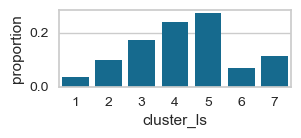

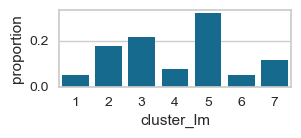

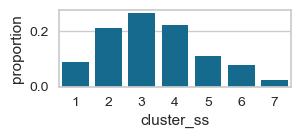

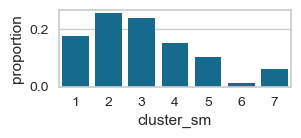

In [12]:
for c_col in cluster_cols:
    plt.figure(figsize = (3, 1))
    sns.barplot(clusters[c_col].value_counts(normalize = True))
    plt.show()

In [13]:
clusters.groupby('cluster_ls')[blight_cols].median().iloc[:, ::2]

,viols_log,low_log,high_log
cluster_ls,,,
1,3.76,2.20,1.74
2,4.83,3.07,2.55
3,5.34,3.58,3.05
4,5.95,4.07,3.49
5,6.39,4.52,3.97
6,5.60,4.67,4.46
7,7.03,5.12,4.49


In [14]:
clusters.groupby('cluster_lm')[blight_cols].median().iloc[:, ::2]

,viols_log,low_log,high_log
cluster_lm,,,
1,3.95,2.38,1.89
2,5.11,3.28,2.77
3,5.91,3.94,3.35
4,5.23,4.09,3.64
5,6.33,4.48,3.93
6,5.69,4.92,4.69
7,7.03,5.10,4.46


In [15]:
clusters.groupby('cluster_ss')[blight_cols].median().iloc[:, 1::2]

,viols_sqrt,low_sqrt,high_sqrt
cluster_ss,,,
1,8.71,3.75,2.80
2,13.75,5.65,4.31
3,19.30,7.70,5.74
4,24.89,9.40,7.07
5,21.65,11.17,8.95
6,36.27,12.21,9.09
7,32.53,17.81,13.02


In [16]:
clusters.groupby('cluster_sm')[blight_cols].median().iloc[:, 1::2]

,viols_sqrt,low_sqrt,high_sqrt
cluster_sm,,,
1,10.88,4.58,3.46
2,16.36,6.74,5.03
3,22.00,8.47,6.28
4,22.70,10.61,8.47
5,29.77,9.66,7.51
6,14.24,16.46,12.91
7,37.39,13.54,9.86


In [17]:
skew(np.sqrt(data))

array([0.59438841, 0.89054617, 0.95310235])

In [18]:
pd.DataFrame(StandardScaler().fit_transform(np.sqrt(data)), columns = data.columns).describe()

,viols_score,low_score,high_score
count,144031.00,144031.00,144031.00
mean,0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.59,-2.70,-2.65
25%,-0.73,-0.68,-0.69
50%,-0.07,-0.06,-0.09
75%,0.52,0.51,0.58
max,3.10,5.14,5.70


In [19]:
clusters.query('cluster_ss == 7').groupby('nbrhd')[blight_cols[1::2]].median()

,viols_sqrt,low_sqrt,high_sqrt
nbrhd,,,
Allegheny Center,20.38,15.61,11.82
Bluff,12.16,16.74,12.73
Central Business District,15.88,21.46,17.62
East Allegheny,21.04,16.05,11.91
South Side Flats,38.09,17.36,12.68


In [20]:
clusters.query('cluster_sm == 6').groupby('nbrhd')[blight_cols[1::2]].median()

,viols_sqrt,low_sqrt,high_sqrt
nbrhd,,,
Allegheny Center,15.27,14.89,11.60
Bluff,11.22,15.20,11.20
Central Business District,13.34,18.65,14.94
Crawford-Roberts,12.24,14.62,11.28
East Allegheny,20.33,16.07,11.93
East Liberty,13.64,11.97,12.71
North Shore,11.18,14.02,11.26


In [21]:
clusters.query('cluster_sm == 7').groupby('nbrhd')[blight_cols[1::2]].median()

,viols_sqrt,low_sqrt,high_sqrt
nbrhd,,,
Allentown,37.77,13.65,9.70
Beltzhoover,37.38,12.32,9.07
Central Oakland,40.88,11.25,8.89
Homewood North,35.24,13.20,9.74
Homewood South,33.36,13.73,9.94
Knoxville,38.34,12.61,9.14
Mount Washington,33.92,12.74,9.42
Mt. Oliver,35.15,12.08,8.47
South Oakland,41.70,10.36,8.17


In [47]:
# color_continuous_scale=[
#         '#440154', '#443983', '#31688e', '#21918c',
#         '#35b779', '#90d743', '#fde725'
# ]

# fig = px.scatter_mapbox(parcels, lat = 'lat', lon = 'lng', color = 'cluster_sm', color_continuous_scale = color_continuous_scale, zoom = 10,
#                         hover_data = ['nbrhd'])
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.show()

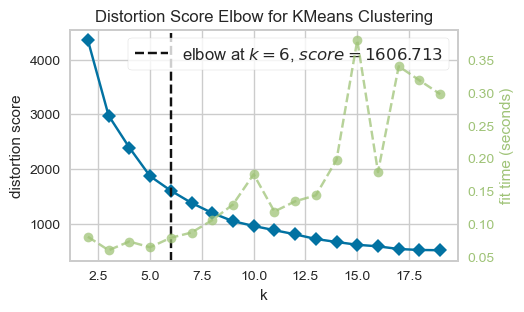

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [22]:
# finding n_clusters
np.random.seed(0)
km = KMeans()

fig, ax = plt.subplots(figsize = (5, 3))
elbow = KElbowVisualizer(km, k = np.arange(2, 20), ax = ax)
elbow.fit(sqrt_minmax)
elbow.show()

In [23]:
np.random.seed(0)
km = KMeans(n_clusters = 7)
parcels['blight'] = km.fit_predict(sqrt_minmax)

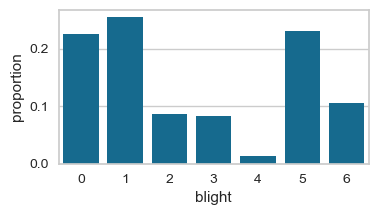

In [24]:
# plt.figure(figsize = (4, 2))
# sns.barplot(parcels['blight'].value_counts(normalize = True))
# plt.show()

plt.figure(figsize = (4, 2))
sns.barplot(parcels['blight'].value_counts(normalize = True))
plt.show()

In [25]:
pca = PCA(n_components = 1)
parcels['pc_blight'] = pca.fit_transform(sqrt_minmax)

In [26]:
parcels.groupby('blight')['pc_blight'].median().sort_values()

blight
6   -0.34
0   -0.18
1   -0.01
3    0.03
5    0.16
4    0.31
2    0.43
Name: pc_blight, dtype: float64

In [27]:
sqrt_labels = {
    6: 1,
    0: 2,
    1: 3,
    3: 4,
    5: 5,
    2: 6,
    4: 7
}

parcels['blight_'] = parcels['blight'].map(sqrt_labels)
parcels['blight'] = parcels['blight_']
parcels = parcels.drop(columns = 'blight_')

In [2]:
# color_continuous_scale=[
#         '#440154', '#443983', '#31688e', '#21918c',
#         '#35b779', '#90d743', '#fde725'
# ]

# fig = px.scatter_mapbox(parcels, lat = 'lat', lon = 'lng', color = 'blight', color_continuous_scale = color_continuous_scale, zoom = 10,
#                         hover_data = ['nbrhd'])
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.show()

In [1]:
# fig = px.scatter_mapbox(parcels.assign(Blight = parcels['pc_blight']), lat = 'lat', lon = 'lng', color = 'Blight', color_continuous_scale = color_continuous_scale, zoom = 10,
#                         hover_data = ['nbrhd'])
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.show()

In [28]:
parcels.to_csv(clean + 'blight.csv', index = False)

In [4]:
parcels = pd.read_csv(clean + 'blight.csv')

### Gaussian Mixture Model clustering

In [ ]:
np.random.seed(0)

X = parcels[['viols_sqrt', 'low_sqrt', 'high_sqrt']]

scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

gmm = GaussianMixture(n_components = 7)
parcels['gmm_cluster'] = gmm.fit_predict(scaled)

In [ ]:
parcels['gmm_cluster'].value_counts(normalize = True) * 100

gmm_cluster
1   24.54
0   23.64
3   21.93
6   10.39
2    9.81
4    7.74
5    1.96
Name: proportion, dtype: float64

In [ ]:
parcels['gmm_cluster'] = parcels['gmm_cluster'].map({
    4: 1,
    0: 2,
    6: 3,
    3: 4,
    1: 5,
    2: 6,
    5: 7
})

In [ ]:
parcels.groupby('gmm_cluster')[cols].mean()

In [3]:
# color_continuous_scale=[
#         '#440154', '#443983', '#31688e', '#21918c', '#35b779', '#90d743', '#fde725'
# ]

# fig = px.scatter_mapbox(parcels, lat = 'lat', lon = 'lng', color = 'gmm_cluster', color_continuous_scale = color_continuous_scale, zoom = 10,
#                         hover_data = ['nbrhd'])
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.show()

### Variable breakdown by cluster

In [6]:
sqrt_cols = ['viols_sqrt', 'low_sqrt', 'high_sqrt']

In [7]:
(
    parcels
    .groupby('blight')[sqrt_cols].median()
    .reset_index()
    .rename(columns = {
        'viols_sqrt': 'Code violations',
        'low_sqrt': 'Low-sev crimes',
        'high_sqrt': 'High-sev crimes'
    })
    .sort_values(by = 'Code violations')
)

,blight,Code violations,Low-sev crimes,High-sev crimes
0,1,9.17,3.99,2.97
1,2,14.30,5.92,4.49
6,7,15.18,16.29,12.73
3,4,17.04,9.53,8.17
2,3,20.53,7.86,5.80
4,5,25.33,10.00,7.62
5,6,37.11,12.78,9.36


In [ ]:
(
    parcels
    .query('blight_sqrt == 6')
    #['nbrhd'].value_counts(normalize = True)
    .groupby('nbrhd')[sqrt_cols].median()
    .sort_values(by = 'viols_sqrt')
)

,viols_sqrt,low_sqrt,high_sqrt
nbrhd,,,
Homewood West,30.98,12.62,9.08
Mount Washington,32.83,12.38,9.17
Homewood South,33.23,13.64,9.87
Mt. Oliver,33.72,11.79,8.39
Homewood North,34.44,12.95,9.53
Arlington Heights,36.16,8.58,7.23
Beltzhoover,36.44,11.23,8.35
Knoxville,37.33,12.38,9.00
Allentown,37.70,13.63,9.69


In [30]:
minmax = MinMaxScaler()
parcels['scaled_viols_sqrt'] = minmax.fit_transform(pd.DataFrame(parcels['viols_sqrt']))
parcels['scaled_low_sqrt'] = minmax.fit_transform(pd.DataFrame(parcels['low_sqrt']))
parcels['scaled_high_sqrt'] = minmax.fit_transform(pd.DataFrame(parcels['high_sqrt']))

In [31]:
parcels.groupby('blight')[['scaled_viols_sqrt', 'scaled_low_sqrt', 'scaled_high_sqrt']].mean()

,scaled_viols_sqrt,scaled_low_sqrt,scaled_high_sqrt
blight,,,
1,0.20,0.16,0.15
2,0.32,0.25,0.23
3,0.47,0.33,0.29
4,0.37,0.40,0.43
5,0.58,0.43,0.39
6,0.83,0.53,0.48
7,0.34,0.75,0.73


Property Code Violations


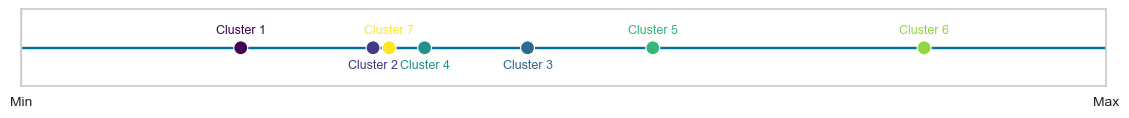

Low-Severity Crime Incidents


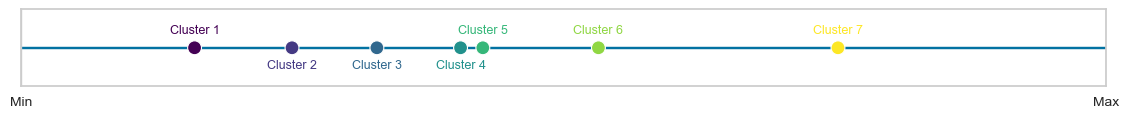

High-Severity Crime Incidents


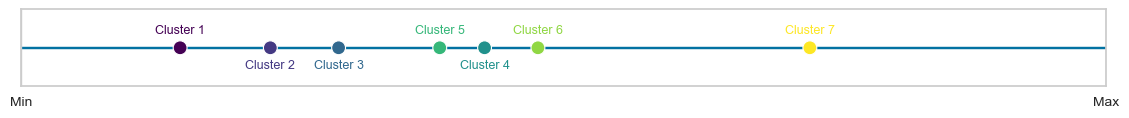

In [32]:
for col, name in zip(['scaled_viols_sqrt', 'scaled_low_sqrt', 'scaled_high_sqrt'], ['Property Code Violations', 'Low-Severity Crime Incidents', 'High-Severity Crime Incidents']):
    print(name)
    toPlot = (
        parcels.groupby('blight')[['scaled_viols_sqrt', 'scaled_low_sqrt', 'scaled_high_sqrt']]
        .mean()[col]
        .reset_index()
        .assign(y=1)
    )

    color_continuous_scale = [
        '#440154', '#443983', '#31688e', '#21918c', '#35b779', '#90d743', '#fde725'
    ]

    plt.figure(figsize=(14, 1))
    sns.scatterplot(
        data=toPlot,
        x=col, y='y',
        hue='blight',
        s=100,
        palette=color_continuous_scale
    )
    plt.xlim((0, 1.0))
    plt.xlabel('')
    plt.xticks([0.0, 1.0], ['Min', 'Max'])
    plt.ylim((0.9, 1.1))
    plt.ylabel('')
    plt.yticks([])

    plt.legend([], [])  # optional

    plt.axhline(xmin=0, xmax=1, y=1, zorder=0)

    # offsets: positive = above, negative = below
    offsets = {
        1: +0.03,
        2: -0.03,
        3: -0.03,  # flip cluster 3 below
        4: -0.03,
        5: +0.03,  # flip cluster 5 below
        6: +0.03,
        7: +0.03
    }

    # Annotate with offsets
    for idx, row in toPlot.iterrows():
        cluster = int(row['blight'])
        plt.text(
            row[col],
            row['y'] + offsets.get(cluster, 0.03),  # default offset if not in dict
            f'Cluster {cluster}',
            ha='center', va='bottom' if offsets.get(cluster, 0.03) > 0 else 'top',
            fontsize=9,
            color=color_continuous_scale[cluster - 1]
        )

    plt.show()

In [34]:
parcels.loc[parcels['blight'] == 6]['nbrhd'].value_counts(normalize = True)

nbrhd
South Side Flats    0.23
South Side Slopes   0.16
Homewood North      0.12
Allentown           0.12
Knoxville           0.10
Central Oakland     0.07
South Oakland       0.06
Homewood South      0.06
Beltzhoover         0.04
Mount Washington    0.02
Mt. Oliver          0.00
Arlington Heights   0.00
Homewood West       0.00
Name: proportion, dtype: float64

In [35]:
parcels.loc[parcels['blight'] == 5]['nbrhd'].value_counts(normalize = True)

nbrhd
Bloomfield              0.07
Mount Washington        0.06
Middle Hill             0.06
Garfield                0.05
Central Northside       0.05
                        ... 
Crafton Heights         0.00
Point Breeze North      0.00
North Oakland           0.00
Spring Hill-City View   0.00
Allegheny Center        0.00
Name: proportion, Length: 53, dtype: float64

In [36]:
parcels.loc[parcels['nbrhd'] == 'East Liberty']['blight'].value_counts(normalize = True)

blight
4   0.67
5   0.29
3   0.04
Name: proportion, dtype: float64

In [37]:
parcels.loc[parcels['nbrhd'] == 'Squirrel Hill North']['blight'].value_counts(normalize = True)

blight
2   0.63
1   0.22
4   0.13
3   0.03
Name: proportion, dtype: float64

In [38]:
parcels.loc[parcels['nbrhd'] == 'Lincoln-Lemington-Belmar']['blight'].value_counts(normalize = True)

blight
3   0.52
5   0.32
2   0.12
1   0.04
Name: proportion, dtype: float64

In [39]:
parcels.loc[parcels['nbrhd'] == 'Homewood West']['blight'].value_counts(normalize = True)

blight
5   0.81
4   0.10
3   0.05
6   0.04
Name: proportion, dtype: float64

In [40]:
parcels.loc[parcels['nbrhd'] == 'Hays']['blight'].value_counts(normalize = True)

blight
1   1.00
Name: proportion, dtype: float64

In [41]:
parcels.loc[parcels['nbrhd'] == 'Shadyside']['blight'].value_counts(normalize = True)

blight
4   0.86
2   0.12
1   0.02
3   0.01
Name: proportion, dtype: float64

In [42]:
parcels.loc[parcels['nbrhd'] == 'South Oakland']['blight'].value_counts(normalize = True)

blight
6   0.49
5   0.33
3   0.17
2   0.01
Name: proportion, dtype: float64

In [ ]:
parcels.to_csv(clean + 'blight.csv', index = False)

In [ ]:
parcels = pd.read_csv(clean + 'blight.csv')

In [ ]:
parcels.groupby('blight_sqrt')[['viols_count_decayed', 'low_count_decayed', 'high_count_decayed']].corr()#.iloc[::3, 1:]#'high_count_decayed'

viols_count_decayed  low_count_decayed  \
blight_sqrt                                                               
1           viols_count_decayed                 1.00               0.41   
            low_count_decayed                   0.41               1.00   
            high_count_decayed                  0.37               0.85   
2           viols_count_decayed                 1.00              -0.03   
            low_count_decayed                  -0.03               1.00   
            high_count_decayed                 -0.12               0.82   
3           viols_count_decayed                 1.00               0.07   
            low_count_decayed                   0.07               1.00   
            high_count_decayed                  0.05               0.76   
4           viols_count_decayed                 1.00               0.25   
            low_count_decayed                   0.25               1.00   
            high_count_decayed                  0.13               0.43   
5           viols_count_decayed                 1.00              -0.31   
            low_count_decayed                  -0.31               1.00   
            high_count_decayed                 -0.24               0.86   
6           viols_count_decayed                 1.00               0.02   
            low_count_decayed                   0.02               1.00   
            high_count_decayed                  0.05               0.96   
7           viols_count_decayed                 1.00               0.20   
            low_count_decayed                   0.20               1.00   
            high_count_decayed                  0.09               0.99   

                                 high_count_decayed  
blight_sqrt                                          
1           viols_count_decayed                0.37  
            low_count_decayed                  0.85  
            high_count_decayed                 1.00  
2           viols_count_decayed               -0.12  
            low_count_decayed                  0.82  
            high_count_decayed                 1.00  
3           viols_count_decayed                0.05  
            low_count_decayed                  0.76  
            high_count_decayed                 1.00  
4           viols_count_decayed                0.13  
            low_count_decayed                  0.43  
            high_count_decayed                 1.00  
5           viols_count_decayed               -0.24  
            low_count_decayed                  0.86  
            high_count_decayed                 1.00  
6           viols_count_decayed                0.05  
            low_count_decayed                  0.96  
            high_count_decayed                 1.00  
7           viols_count_decayed                0.09  
            low_count_decayed                  0.99  
            high_count_decayed                 1.00

In [ ]:
parcels[['viols_count_decayed', 'low_count_decayed', 'high_count_decayed']].corr()

,viols_count_decayed,low_count_decayed,high_count_decayed
viols_count_decayed,1.00,0.56,0.47
low_count_decayed,0.56,1.00,0.95
high_count_decayed,0.47,0.95,1.00


In [4]:
# plt.figure(figsize = (8, 6))
# sns.scatterplot(parcels, x = 'viols_count_decayed', y = 'low_count_decayed', hue = 'blight_sqrt', palette = 'viridis')
# plt.show()

In [5]:
# sns.scatterplot(parcels, x = 'viols_count_decayed', y = 'low_count_decayed', hue = 'blight_sqrt')
# plt.show()

In [6]:
# sns.scatterplot(parcels, x = 'viols_count_decayed', y = 'high_count_decayed', hue = 'blight_sqrt')
# plt.show()

In [ ]:
toPlot = (
    parcels
    .assign(nbrhd = np.where(parcels['nbrhd'].str.contains('Homewood'), 'Homewood', parcels['nbrhd']))
    .assign(nbrhd = lambda x: np.where(parcels['nbrhd'].str.contains('Oakland'), 'Oakland', x['nbrhd']))
)

In [7]:
# sns.scatterplot(toPlot.loc[(
#     toPlot['nbrhd'].str.contains('Homewood|Allentown|Knoxville|Southside|Beltzhoover|Oakland|Washington|Oliver', case=False, na=False)
# ) & (toPlot['blight_sqrt'] == 6)], x = 'viols_count_decayed', y = 'high_count_decayed', hue = 'nbrhd')
# plt.show()